In [1]:
# import packages needed throughout
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns

# Data Preprocessing

The code under Data Preprocessing is written such that you can start from any header and read in the necessary files (as long as those files have been created and saved before) instead of starting from the beginning each time. 

## Data Merging

In [ ]:
from data_prep import unzip_data, merge_data

In [ ]:
# Run only if original OULAD data is needed
# Unzips OULAD data and loads each csv file
zip_file = "Data/OULAD.zip" # "C:/Users/jacma/OneDrive/school work/UMD/Data Science Boot Camp/Group Project/Data/OULAD.zip"
assessments, courses, studentAssessments, studentInfo, studentRegistration, studentVLE, VLEdata = unzip_data(zip_file)

assessments.to_csv("Data/assessments_OULAD.csv", index=False) # save for easy importing since it will be needed in subsequent code

In [ ]:
# Run to create csv with merged data (merges data from separate OULAD csv files) 
zip_file = "Data/OULAD.zip" # "C:/Users/jacma/OneDrive/school work/UMD/Data Science Boot Camp/Group Project/Data/OULAD.zip"
merged_file = "Data/merged_data.csv" # "C:/Users/jacma/OneDrive/school work/UMD/Data Science Boot Camp/Group Project/Data/merged_data.csv"
df = merge_data(zip_file, merged_file)

In [ ]:
from IPython.display import Image
image_path = "data merging.png" # "C:/Users/jacma/OneDrive/school work/UMD/Data Science Boot Camp/Group Project/data merging.png"
Image(filename=image_path, width=800, height=800)

## EDA: Module-Presentation Comparison <br>
Module = one of seven courses (4 STEM, 3 Social Sciences) <br>
Presentation = year (2013 or 2014) and semester (B = starts in February; J = starts in October) <br>

Brief exploratory data analysis to: 
1. compare module-presentation lengths, number of students taking the module-presentation, and number of assessments due in each module-presentation
2. inform choice of variable to use for our target
3. explore when assessments are due throughout each module-presentation and if any could be useful as an early indicator 
4. explore magnitude of VLE interactions throughout each module-presentation to inform: (1) whether to use all module-presentations in final analyses, and (2) what timeframe could be considered 'early' and still have enough data for modeling 

In [ ]:
# run this code block only if not continuing from above
sns.set_style("whitegrid")
df = pd.read_csv("Data/merged_data.csv")

In [ ]:
from get_course_info import course_meta_info

# Obtain metadata about each module-presentation ("course") 
course_info = course_meta_info(df, meta=['length','num_students','num_assessments','percent_outcomes'],output = False)
course_info

In [ ]:
# 1. Plot number of assessments in each module-presentation by assessment type
# Assessment types: 
# - Exam (Final Exam)
# - CMA (Computer Marked Assessment)
# - TMA (Tutor Marked Assessment)

assessments_in_course = (df
    .groupby(["code_module", "code_presentation","assessment_type"], as_index=False)
    .agg(num_assessments=("id_assessment", "nunique")
    )
)

g = sns.catplot(
    data=assessments_in_course,
    x="assessment_type",
    y="num_assessments",
    hue="code_module",
    col="code_presentation", 
    kind="bar",
    height=4,
    aspect=1
)

g.set_axis_labels("Assessment Type", "Number of Assessments")  
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("Number of Assessments by Type, Module, and Presentation")
plt.show()

We noted that the assessment 'Exam' is not available in most module-presentations, so the final exam score could not be used as our target. <br>
The other option for our target is the categorical outcome 'final_result': Distinction, Pass, Withdrawn, Fail. 

In [ ]:
# 2. Visualize the distribution of final_result across module-presentations. 
outcomes_in_course = (
    df
    .groupby(["code_module", "code_presentation","final_result"], as_index=False)
    .agg(
        num_students=("id_student", "nunique")
    )
)

g = sns.catplot(
    data=outcomes_in_course,
    x="final_result",
    y="num_students",
    hue="code_module",
    col="code_presentation",  
    kind="bar",
    height=4,
    aspect=1
)

g.set_axis_labels("Final Result", "Number of Students")  
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("Number of Students by Result, Module, and Presentation")
plt.show()

In [ ]:
# 3. Visualize distribution of assessment due dates for each module-presentation by assessment type

assessment_duedates = df[
    ["code_module", "code_presentation", "id_assessment", "assessment_type", "due_date", "weight"]
].dropna(subset=["id_assessment"]).drop_duplicates().sort_values("code_module")

g = sns.catplot(
    data=assessment_duedates,
    x="due_date",
    y="assessment_type",
    hue="code_module",
    col="code_presentation",
    kind="swarm",    
    dodge=True,
    alpha=0.7,
    height=4,
    aspect=1
)

g.set_axis_labels("Assessment Due Date", "Assessment Type")  
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("Due Dates of Assessments by Type, Module, and Presentation")
plt.show()

In [ ]:
# 4. Compute daily average VLE interactions using all students in a module-presentation 
vle_columns = [
    'forumng', 'homepage', 'oucontent', 'subpage', 'url', 'resource', 
    'glossary', 'dataplus', 'oucollaborate', 'quiz', 'ouelluminate', 
    'sharedsubpage', 'questionnaire', 'page', 'externalquiz', 'ouwiki', 
    'dualpane', 'repeatactivity', 'folder', 'htmlactivity'
]

df["total_vle_interactions"] = df[vle_columns].sum(axis=1)
daily_avg_vle = df.groupby(["code_module","code_presentation","date"], as_index=False).agg(avg_vle=("total_vle_interactions", "mean"), num_active_students=("id_student","nunique"))
daily_avg_vle = daily_avg_vle.merge(course_info[["code_module","code_presentation","num_students"]], on=["code_module", "code_presentation"], how="left")

# Determine the percentage of active students on a given day for each module-presentation
daily_avg_vle["percent_active_students"] = daily_avg_vle["num_active_students"]/daily_avg_vle["num_students"]*100

In [ ]:
# Plot average daily VLE interactions throughout the span of each module-presentation
g = sns.relplot(
    data=daily_avg_vle,
    x="date",
    y="avg_vle",
    hue="code_presentation",  
    kind="line",
    col="code_module",         
    col_wrap=3,                
    height=3.5,                
    aspect=1.3,               
    facet_kws={"sharey": False, "sharex": False}
)

# Titles and labels
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Date (relative to start)", "Average VLE interactions")
g.fig.suptitle("VLE Interactions Over Time by Module and Presentation", y=1.05)
plt.tight_layout()
plt.show()

In [ ]:
# Plot percentage of active students on each day 
g = sns.relplot(
    data=daily_avg_vle,
    x="date",
    y="percent_active_students",
    hue="code_presentation",  
    kind="line",
    col="code_module",       
    col_wrap=3,                
    height=3.5,              
    aspect=1.3,               
    facet_kws={"sharey": False, "sharex": False}
)

# Titles and labels
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Date (relative to start)", "Percent active students")
g.fig.suptitle("VLE Interactions Over Time by Module and Presentation", y=1.05)
plt.tight_layout()
plt.show()

From these two plots, we noticed that peaks of VLE interactions occur (and subsequent analyses supported that these occur around the time when assessments are due). However, the peaks for a given module-presentation do not occur on the same relative day of the course. A shift for the 'J' presentations occurs (starting at around days ~60-80) due to the winter holiday, which also explains why the 'J' presentations are ~10-20 days longer than the "B" presentations of the same module. Since we are focused on identifying early risk factors, we will be using features from the dataset occurring well before day 50+ of the courses, so this shift will not influence our analyses.  <br>

We also noticed that there is VLE interaction data that extends well beyond the end of the module-presentation lengths. So we looked into that briefly below and found that several assessments were submitted after the end of the course and explains why there are data in the figures above as far out as 600 days. 

In [ ]:
# Calculate number of students that turn in assessments beyond the end of the course, and what the latest (max) date of submission was
assessments_after_end = df[df["date"] > df["module_presentation_length"]]
summary = assessments_after_end.groupby(
    [ "code_module", "code_presentation","module_presentation_length","id_assessment", "assessment_type", "due_date"]
).agg(
    num_students=("id_student", "nunique"),
    min_date=("date", "min"),
    max_date=("date", "max")
).reset_index()

summary

## Feature Calculation

This section calculates additional features from the original data (i.e., engineered features) to use in our models calculated for the specified timeframe (n_weeks). 

The engineered features include: <br>
- Diversity metrics: 
    - Richness
    - Entropy
- Regularity metrics:
    - Standard deviation of gaps
    - Standard deviation of active days per week
- Submission metrics:
    - Early/Late/Never (relative to due date, when did student submit assessment) 
    - Yes/No (binary) 
- Combined metrics:
    - Total VLE interactions
    - Assessment focus
    - Content focus
    - Collaboration focus

In [ ]:
# run this code block only if not continuing from above
df = pd.read_csv("Data/merged_data.csv") # pd.read_csv("C:/Users/jacma/OneDrive/school work/UMD/Data Science Boot Camp/Group Project/Data/merged_data.csv")
assessments = pd.read_csv("Data/assessments_OULAD.csv")

Given our EDA, we decided to use the pre-course period up through the first 3 weeks as our timeframe to identify early risk factors, but this can be changed by the user. 

In [ ]:
n_weeks=3 # User-selected timeframe over which to subset data and calculate features

In [ ]:
from feature_calculator import vle_features, assessment_features
from combine_tables import combine_tables

# Generate engineered features on vle interaction data
df_vle_early = vle_features(df,features=['total','focus','regularity','diversity'], 
                            n_weeks=n_weeks, write_to="Data/")

# Generate engineered features on assessment data
df_assessments_early = assessment_features(df,assessments,features=['submission'], write_to="Data/")

# Combine vle & assessment data tables
df_early = combine_tables(df_vle_early,df_assessments_early)

# Add demographics data 
demographics_cols = ['gender','region','highest_education','imd_band', 'age_band',
                     'num_of_prev_attempts','studied_credits', 'disability']
df_demographics = df[['id_student','code_module','code_presentation'] + demographics_cols].drop_duplicates()
df_early = combine_tables(df_early,df_demographics)

# Save to csv
df_early.to_csv(f"Data/data_pre_thru_week{n_weeks}.csv", index=False)

## Data Selection

This section subsets the dataset to exclude: <br>
- certain student profiles that add more confounding variables we do not want to account for in this model
- certain module-presentations that do not have the data needed for the model in the first n_weeks of the course 

This is the final dataset used in the models. 

In [ ]:
# run this code block only if not continuing from above
n_weeks=3 # User-selected timeframe over which to subset data and calculate features
df_early = pd.read_csv(f"Data/data_pre_thru_week{n_weeks}.csv")
assessments = pd.read_csv("Data/assessments_OULAD.csv")

In [ ]:
from data_selection import student_selection, course_selection

# retain students that have not withdrawn within the first n_weeks and have not attempted the course more than the specified max_num_attemps
df_early_subset = student_selection(df_early,n_weeks=n_weeks,max_num_attempts=0) 
# keep module-presentations that have an assessment due in the first n_weeks 
df_early_subset = course_selection(df_early_subset, assessments, n_weeks=n_weeks)

In [ ]:
from data_selection import check_samplesize

# Check final sample size 
check_samplesize(df_early, df_early_subset)

In [ ]:
# Save to csv
df_early_subset.to_csv(f"Data/subset_data_pre_thru_week{n_weeks}.csv", index=False) # renamed combined_presentations_data_w3.csv
df_early_subset.head()

In [ ]:
df = df_early_subset

# Modeling Procedures

## Define models

In [2]:
# run this code block only if not continuing from above
n_weeks=3 # User-selected timeframe over which to subset data and calculate features
df = pd.read_csv(f"Data/subset_data_pre_thru_week{n_weeks}.csv") 

In [3]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from xgboost.sklearn import XGBClassifier
from sklearn.dummy import DummyClassifier

from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.base import clone
from sklearn.metrics import confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score, accuracy_score
from sklearn.model_selection import StratifiedKFold

In [4]:
# Set random seed for reproducibility
import random
import numpy as np

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print(f"Random seed set to {SEED}")

Random seed set to 42


In [5]:
# Define preprocessors
scale_cols = ['content_focus_pre_w3', 'collaborative_focus_pre_w3', 'active_days_per_week_pre_w3',
            'std_regularity_pre_w3', 'vle_richness_pre_w3', 'diversity_shannon_pre_w3', 
            'total_vle_pre_w3']
cat_cols = ['code_module', 'submission_type']

cat_processor = ColumnTransformer(
    transformers = [('cat_encode', OneHotEncoder(drop='first'), cat_cols)],
    remainder = 'passthrough'
)

catscale_processor = ColumnTransformer(
    transformers = [('scale', RobustScaler(), scale_cols),
                ('cat_encode', OneHotEncoder(drop='first'), cat_cols)],
    remainder = 'passthrough'
)

# Define model pipelines
models = {
    'Baseline (Stratified)': DummyClassifier(strategy='stratified', random_state=SEED),
    'Logistic Regression': Pipeline([('preprocess', catscale_processor), 
                                    ('classify', LogisticRegression(random_state=SEED, max_iter=5000, solver='saga',
                                                                    penalty='elasticnet', l1_ratio=0.5, C=0.1,
                                                                    class_weight='balanced'))]),
    'Random Forest': Pipeline([('preprocess', cat_processor), 
                            ('classify', RandomForestClassifier(random_state=SEED, n_estimators=100, max_depth=6,
                                                                min_samples_split=50, min_samples_leaf=25,
                                                                max_features='sqrt', max_samples=0.7,
                                                                class_weight='balanced'))]),
    'Gradient Boosting': Pipeline([('preprocess', cat_processor),
                                ('classify', GradientBoostingClassifier(random_state=SEED, n_estimators=100, 
                                                                        max_depth=3, learning_rate=0.1))]),
    'Extra Trees': Pipeline([('preprocess', cat_processor),
                            ('classify', ExtraTreesClassifier(random_state=SEED, n_estimators=100, max_depth=6,
                                                            min_samples_split=50, min_samples_leaf=25,
                                                            max_features='sqrt', class_weight='balanced'))]),
    'XGBoost': Pipeline([('preprocess', cat_processor),
                        ('classify', XGBClassifier(random_state=SEED))])
}

## Fit and tune models

In [6]:
from modeler import data_preprocess, model_traintest_split, model_initfit, model_tune
import joblib

In [7]:
# Preprocess data, use cross-validation to examine performances for various models
df_model_clean = data_preprocess(df) 
results_df = model_initfit(df_model_clean, models)

# Display results
print("\nMODEL PERFORMANCE (Cross-Validation)")
print("-" * 80)
print(results_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

print("\n" + "=" * 80)
print("KEY INSIGHTS")
print("=" * 80)

# Get baseline and best model
baseline = results_df[results_df['Model'] == 'Baseline (Stratified)'].iloc[0]
best = results_df.iloc[0]

print(f"\n✓ BEST ROC-AUC: {best['Model']}")
print(f"  • ROC-AUC: {best['Test ROC-AUC']:.3f} (+{best['Test ROC-AUC'] - baseline['Test ROC-AUC']:.3f} vs baseline)")
print(f"  • Recall: {best['Test Recall']:.1%} of at-risk students identified")
print(f"  • Precision: {best['Test Precision']:.1%}")
print(f"  • Overfitting: {best['Overfitting Gap']:.3f} {'✓ Well-controlled' if best['Overfitting Gap'] < 0.10 else '⚠ Moderate'}")

print(f"\n✓ RUNNER-UP ROC-AUC: {results_df.iloc[1]['Model']}")
runner_up = results_df.iloc[1]
print(f"  • ROC-AUC: {runner_up['Test ROC-AUC']:.3f}")
print(f"  • Recall: {runner_up['Test Recall']:.1%} of at-risk students identified")
print(f"  • Precision: {runner_up['Test Precision']:.1%}")
print(f"  • Overfitting: {runner_up['Overfitting Gap']:.3f} {'✓ Excellent' if abs(runner_up['Overfitting Gap']) < 0.05 else '✓ Good'}")


MODEL PERFORMANCE (Cross-Validation)
--------------------------------------------------------------------------------
                Model  Test ROC-AUC  Test Recall  Test Precision  Test F1  Overfitting Gap
  Logistic Regression        0.7081       0.6150          0.5892   0.6017           0.0006
          Extra Trees        0.6981       0.6277          0.5615   0.5927           0.0041
        Random Forest        0.7081       0.5809          0.6035   0.5919           0.0160
    Gradient Boosting        0.7061       0.4533          0.6563   0.5359           0.0279
              XGBoost        0.6672       0.4704          0.5884   0.5227           0.2576
Baseline (Stratified)        0.4983       0.4289          0.4209   0.4249           0.0095

KEY INSIGHTS

✓ BEST ROC-AUC: Logistic Regression
  • ROC-AUC: 0.708 (+0.210 vs baseline)
  • Recall: 61.5% of at-risk students identified
  • Precision: 58.9%
  • Overfitting: 0.001 ✓ Well-controlled

✓ RUNNER-UP ROC-AUC: Extra Trees
  • ROC-

In [ ]:
# Hyperparameter tuning (takes a while to run)
final_models = model_tune(df_model_clean, models)

# Save final_models (since it takes a long time to run) 
joblib.dump(final_models,"final_models.pkl") 

In [8]:
# option to import if final_models.pkl is already saved, 
final_models = joblib.load("final_models.pkl")

## Further analysis

In [9]:
from analysis import metrics_at_thresholds, visualize_thresholds

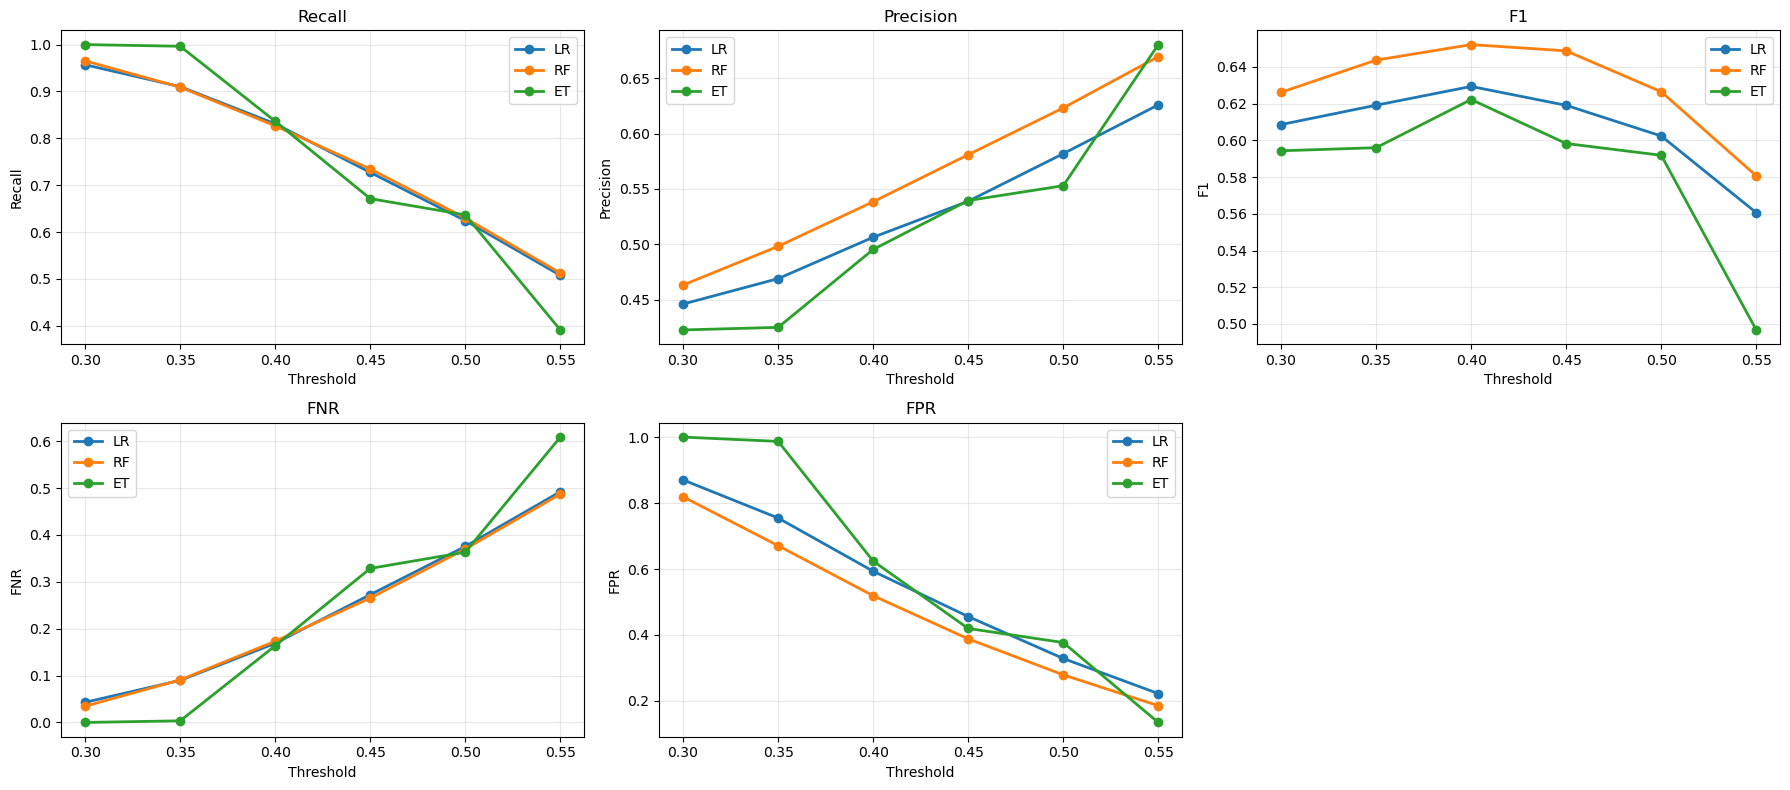

Model  Threshold   Recall  Precision       F1      FNR      FPR
   LR       0.30 0.956999   0.446195 0.608623 0.043001 0.870138
   RF       0.30 0.965336   0.463402 0.626201 0.034664 0.818869
   ET       0.30 1.000000   0.422820 0.594341 0.000000 1.000000
   LR       0.35 0.910268   0.469132 0.619161 0.089732 0.754581
   RF       0.35 0.909171   0.498257 0.643728 0.090829 0.670685
   ET       0.35 0.996490   0.425161 0.596024 0.003510 0.986982
   LR       0.40 0.831066   0.506485 0.629393 0.168934 0.593218
   RF       0.40 0.826678   0.538517 0.652185 0.173322 0.518965
   ET       0.40 0.836332   0.495451 0.622266 0.163668 0.623915
   LR       0.45 0.727293   0.538937 0.619105 0.272707 0.455802
   RF       0.45 0.734533   0.580947 0.648774 0.265467 0.388139
   ET       0.45 0.671347   0.539587 0.598299 0.328653 0.419640
   LR       0.50 0.624397   0.581885 0.602392 0.375603 0.328672
   RF       0.50 0.629882   0.623182 0.626514 0.370118 0.279010
   ET       0.50 0.636683   0.552973 0.5

In [10]:
# Threshold analysis
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55]
tuned_models = [('LR', final_models['Logistic Regression']), 
                ('RF', final_models['Random Forest']), 
                ('ET', final_models['Extra Trees'])]

df_model_clean = data_preprocess(df) 
X_train, X_test, y_test = model_traintest_split(df_model_clean)
y_train = X_train["stratify"].apply(lambda x: int(x[0]))

results = metrics_at_thresholds(thresholds, tuned_models, X_train, y_train)
df_results = pd.DataFrame(results)
visualize_thresholds(df_results)

print(df_results.to_string(index=False))


LR - Top 10 Features
                    Feature     Value
      submission_type_Never  0.969753
       submission_type_Late -0.650790
            code_module_FFF  0.549763
           total_vle_pre_w3 -0.246253
active_days_per_week_pre_w3 -0.157138
            code_module_DDD  0.155710
            code_module_BBB -0.131525
        vle_richness_pre_w3 -0.126085
            code_module_CCC  0.121285
 collaborative_focus_pre_w3 -0.079271

RF - Top 10 Features
                    Feature    Value
      submission_type_Never 0.200129
       submission_type_Late 0.199450
           total_vle_pre_w3 0.175418
 collaborative_focus_pre_w3 0.089311
      std_regularity_pre_w3 0.071711
active_days_per_week_pre_w3 0.060378
   diversity_shannon_pre_w3 0.058592
       content_focus_pre_w3 0.051651
        vle_richness_pre_w3 0.035203
            code_module_FFF 0.019802

ET - Top 10 Features
                    Feature    Value
      submission_type_Never 0.402627
       submission_type_Late 0.31762

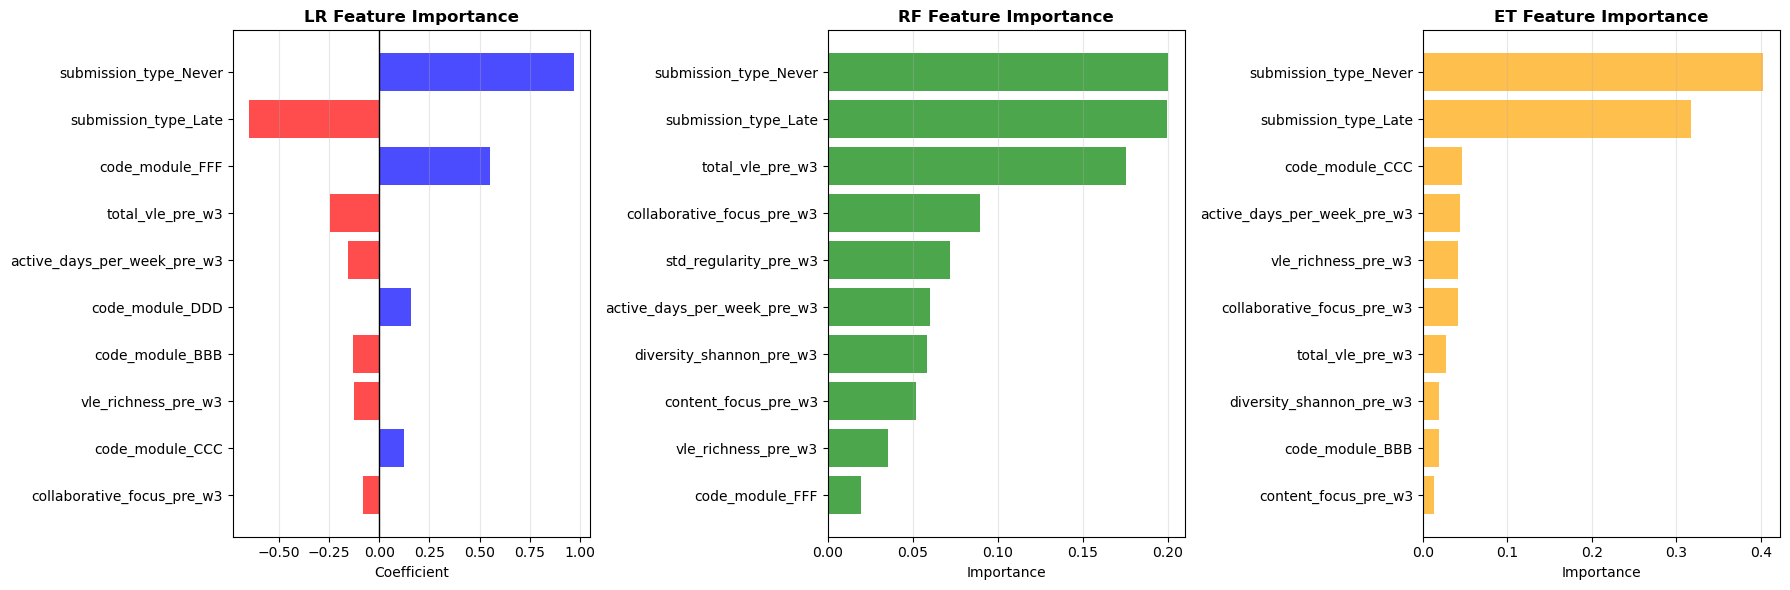

In [15]:
# Feature Importance Analysis
tuned_models = dict(tuned_models)
cat_features = list(tuned_models['LR'].named_steps['preprocess'].
                    named_transformers_['cat_encode'].get_feature_names_out(cat_cols))
all_features = scale_cols + cat_features

# Extract importances
importances = {
    'LR': pd.DataFrame({
        'Feature': all_features,
        'Value': tuned_models['LR'].named_steps['classify'].coef_[0]
    }).sort_values('Value', key=abs, ascending=False),
    'RF': pd.DataFrame({
        'Feature': cat_features + scale_cols,
        'Value': tuned_models['RF'].named_steps['classify'].feature_importances_
    }).sort_values('Value', ascending=False),
    'ET': pd.DataFrame({
        'Feature': cat_features + scale_cols,
        'Value': tuned_models['ET'].named_steps['classify'].feature_importances_
    }).sort_values('Value', ascending=False)
}

# Display top 10
for model, df in importances.items():
    print(f"\n{model} - Top 10 Features")
    print("=" * 60)
    print(df.head(10).to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = {'LR': ['red' if v < 0 else 'blue' for v in importances['LR'].head(10)['Value']], 
          'RF': 'green', 'ET': 'orange'}

for ax, (model, df) in zip(axes, importances.items()):
    top = df.head(10)
    ax.barh(range(len(top)), top['Value'], color=colors[model], alpha=0.7)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(top['Feature'])
    if model == 'LR':
        ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
    ax.set_xlabel('Coefficient' if model == 'LR' else 'Importance')
    ax.set_title(f'{model} Feature Importance', fontweight='bold')
    ax.invert_yaxis()
    ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Test set performance

In [18]:
tuned_lr_model = tuned_models['LR']

TEST SET PERFORMANCE (Threshold = 0.35)
Model  Threshold  Recall  Precision     F1    FNR    FPR
   LR     0.3500  0.9175     0.4720 0.6233 0.0825 0.7508
   RF     0.3500  0.8973     0.4885 0.6326 0.1027 0.6872


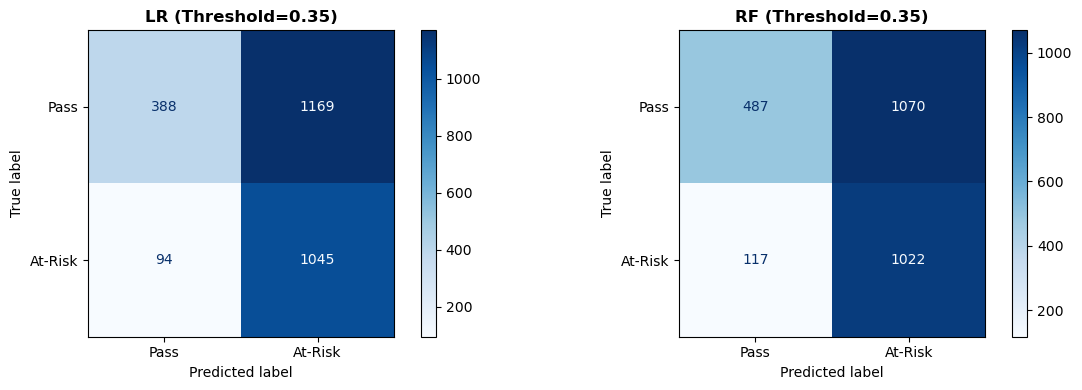

In [21]:
# Test Set Evaluation at Threshold 0.35
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

tuned_lr_model = tuned_models['LR']
tuned_rf_model = tuned_models['RF']
tuned_et_model = tuned_models['ET']

y_test_numeric = y_test if y_test.dtype != 'object' else y_test.apply(lambda x: int(x[0]))
models_eval = [('LR', tuned_lr_model), ('RF', tuned_rf_model)]

# Calculate metrics
results = metrics_at_thresholds([0.35],models_eval, X_test, y_test) # was missing X and y - please check if this is right
print("TEST SET PERFORMANCE (Threshold = 0.35)")
print("=" * 60)
print(pd.DataFrame(results).to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for idx, (name, model) in enumerate(models_eval):
    y_pred = (model.predict_proba(X_test)[:, 1] >= 0.35).astype(int)
    ConfusionMatrixDisplay(confusion_matrix(y_test_numeric, y_pred), 
                          display_labels=['Pass', 'At-Risk']).plot(cmap='Blues', ax=axes[idx], values_format='d')
    axes[idx].set_title(f'{name} (Threshold=0.35)', fontweight='bold')
plt.tight_layout()
plt.show()